In [2]:
# Cell 1: Setup and imports
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import matplotlib.patches as patches

from data.data_loader import collect_dataset2_pairs, load_config

# for better display
plt.rcParams['figure.figsize'] = (15, 8)

print("Setup done")
print(f"Project root: {project_root}")

Setup done
Project root: c:\Users\Rayanafshan\Desktop\HW3_Zanganeh_810104157\homework_code


In [3]:
# Cell 2: Load dataset2 paths (MUST RUN THIS FIRST)
config_path = project_root / "config" / "config.yaml"
cfg = load_config(str(config_path))

config_dir = config_path.parent.parent
ds2_dir = str(config_dir / cfg["data"]["dataset2_dir"])

pairs = collect_dataset2_pairs(ds2_dir)
print(f"Found {len(pairs)} image-mask pairs in dataset2")

# show a few samples
for i, (img_path, mask_path, _) in enumerate(pairs[:3]):
    print(f"{i+1}. Image: {Path(img_path).name}")
    print(f"   Mask:  {Path(mask_path).name}")

Found 100 image-mask pairs in dataset2
1. Image: Frame 1  (1).jpg
   Mask:  Frame 1  (1).jpg___fuse.png
2. Image: Frame 1  (10).jpg
   Mask:  Frame 1  (10).jpg___fuse.png
3. Image: Frame 1  (100).jpg
   Mask:  Frame 1  (100).jpg___fuse.png


In [4]:
# Cell 3: Function to show image and mask (FAST VERSION)
def show_image_and_mask(img_path, mask_path, index=0):
    """
    show original image and mask side by side
    """
    # load image
    image = Image.open(img_path).convert("RGB")
    
    # load mask
    mask = Image.open(mask_path)
    if mask.mode == "RGBA":
        mask = mask.convert("RGB")
    
    # convert to numpy arrays
    img_np = np.array(image)
    mask_np = np.array(mask)
    
    # find unique colors - FASTER method
    pixels = mask_np.reshape(-1, 3)
    # use set for faster unique color finding
    unique_colors_set = set()
    for row in pixels:
        unique_colors_set.add(tuple(row))
        if len(unique_colors_set) > 20:  # stop if we found many colors (mask shouldn't have more than 11)
            break
    color_tuples = list(unique_colors_set)
    
    # display
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # original image
    axes[0].imshow(img_np)
    axes[0].set_title(f"Original Image {index}", fontsize=12)
    axes[0].axis('off')
    
    # rgb mask
    axes[1].imshow(mask_np)
    axes[1].set_title(f"Mask (RGB) {index}", fontsize=12)
    axes[1].axis('off')
    
    # show unique colors as color patches
    axes[2].axis('off')
    axes[2].set_title(f"Unique Colors in Mask ({len(color_tuples)} colors)", fontsize=12)
    
    # show each color as a colored rectangle
    y_start = 0.1
    for i, color in enumerate(sorted(color_tuples)):
        y_pos = y_start + i * 0.07
        rect = patches.Rectangle((0.1, y_pos), 0.1, 0.05, 
                                  facecolor=np.array(color)/255, 
                                  edgecolor='black', linewidth=1)
        axes[2].add_patch(rect)
        axes[2].text(0.25, y_pos + 0.02, f"RGB: {color}", fontsize=9, va='center')
    
    axes[2].set_xlim(0, 1)
    axes[2].set_ylim(0, 1)
    axes[2].invert_yaxis()
    
    plt.tight_layout()
    plt.show()
    
    return color_tuples


Sample 1: Frame 1  (1).jpg


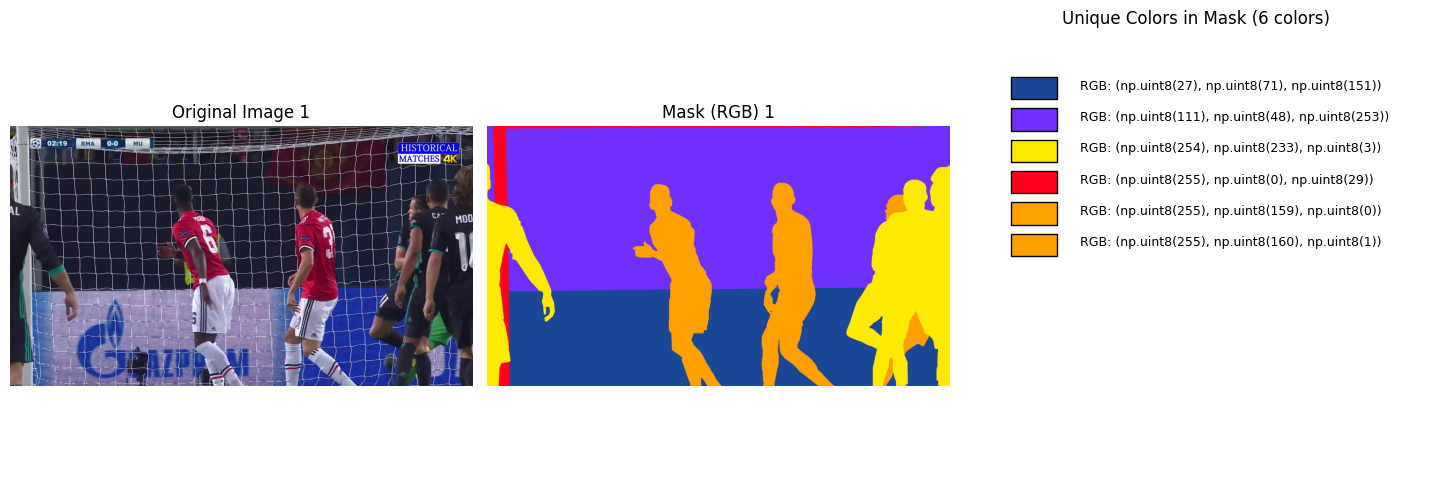


Sample 2: Frame 1  (10).jpg


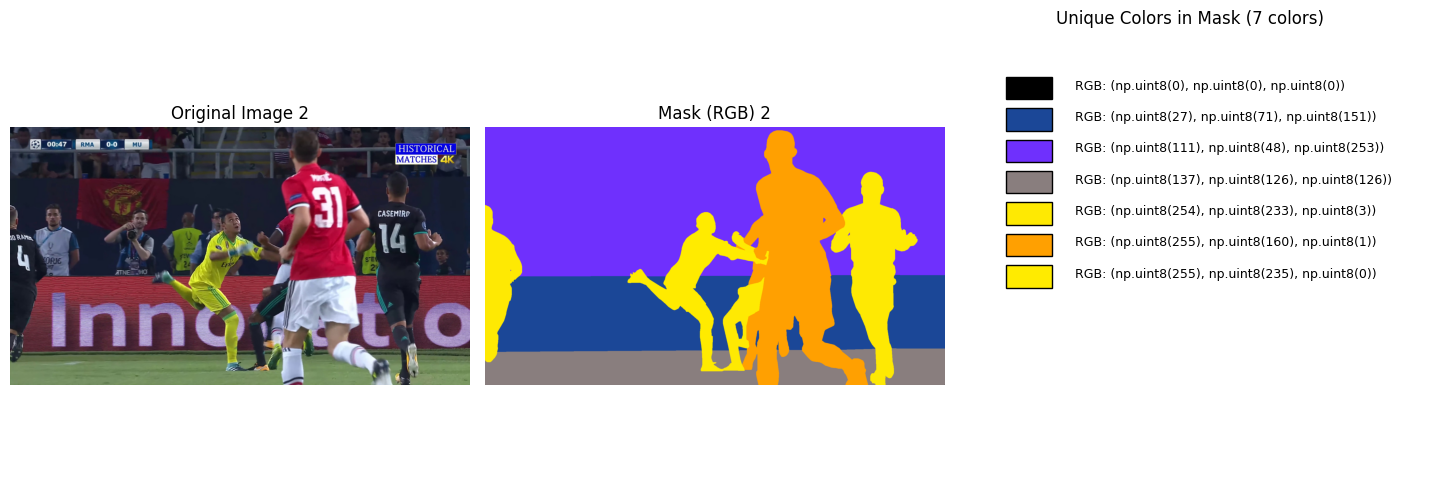


Sample 3: Frame 1  (100).jpg


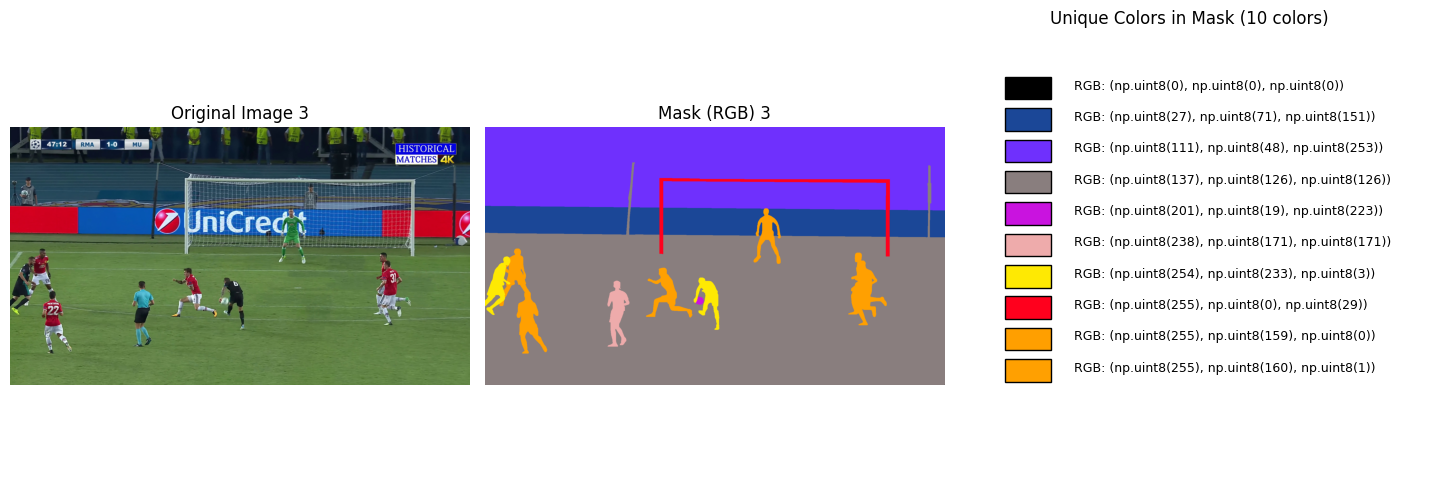


Sample 4: Frame 1  (11).jpg


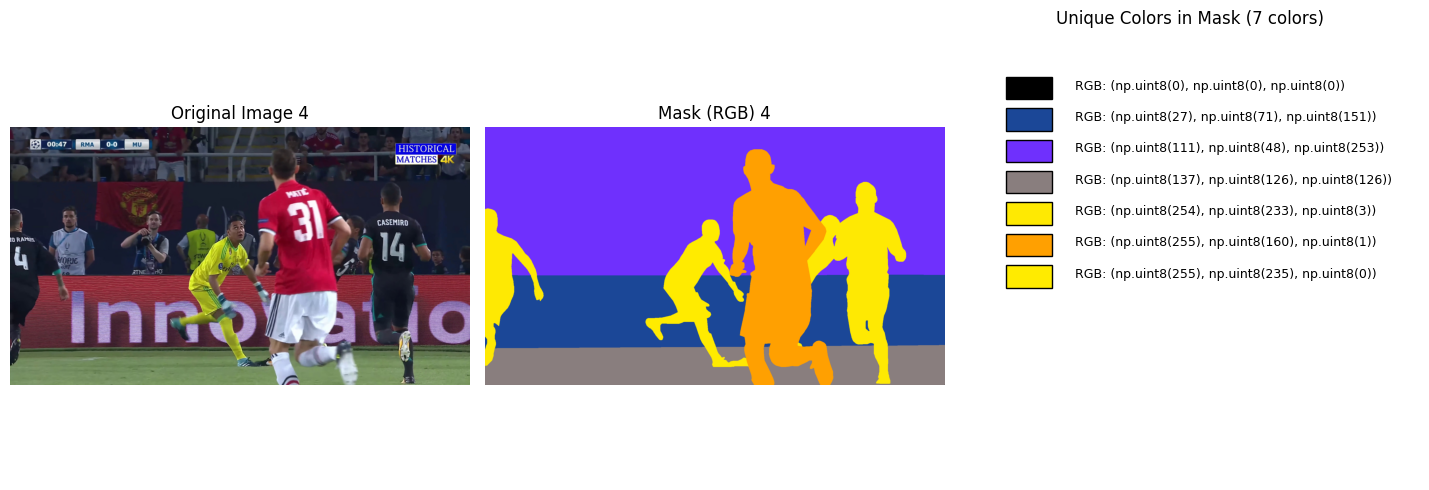


Sample 5: Frame 1  (12).jpg


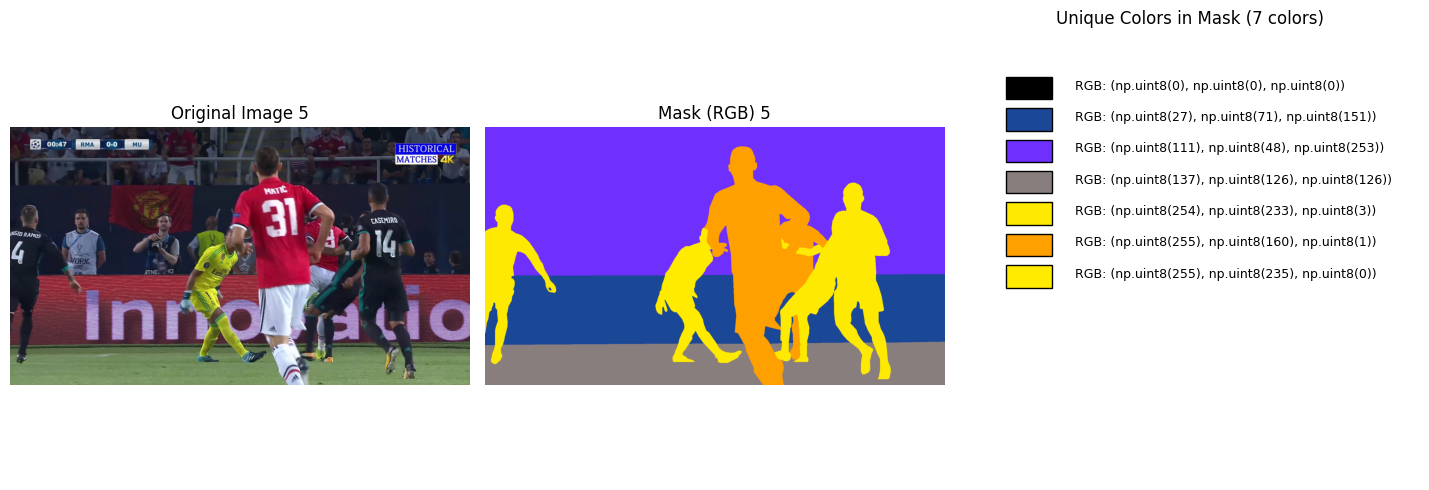

In [5]:
# Cell 4: Check some samples
all_colors = {}

for idx, (img_path, mask_path, _) in enumerate(pairs[:5]):  # change pairs[:x] to number of pictures you want
    print(f"\n{'='*60}")
    print(f"Sample {idx+1}: {Path(img_path).name}")
    print('='*60)
    
    colors = show_image_and_mask(img_path, mask_path, idx+1)
    
    # save colors
    for color in colors:
        all_colors[color] = all_colors.get(color, []) + [Path(img_path).name]
    
    if idx < 2:  # wait after each except last
        input("\nPress Enter to see next sample...")


In [6]:
# Cell 5: Summary of all colors found
print("\n" + "="*60)
print("ALL UNIQUE COLORS FOUND IN DATASET2 MASKS")

print("\nRGB Color -> Appears in these images:")
for color in sorted(all_colors.keys()):
    print(f"\n  {color}:")
    for img_name in all_colors[color][:3]:
        print(f"    - {img_name}")


ALL UNIQUE COLORS FOUND IN DATASET2 MASKS

RGB Color -> Appears in these images:

  (np.uint8(0), np.uint8(0), np.uint8(0)):
    - Frame 1  (10).jpg
    - Frame 1  (100).jpg
    - Frame 1  (11).jpg

  (np.uint8(27), np.uint8(71), np.uint8(151)):
    - Frame 1  (1).jpg
    - Frame 1  (10).jpg
    - Frame 1  (100).jpg

  (np.uint8(111), np.uint8(48), np.uint8(253)):
    - Frame 1  (1).jpg
    - Frame 1  (10).jpg
    - Frame 1  (100).jpg

  (np.uint8(137), np.uint8(126), np.uint8(126)):
    - Frame 1  (10).jpg
    - Frame 1  (100).jpg
    - Frame 1  (11).jpg

  (np.uint8(201), np.uint8(19), np.uint8(223)):
    - Frame 1  (100).jpg

  (np.uint8(238), np.uint8(171), np.uint8(171)):
    - Frame 1  (100).jpg

  (np.uint8(254), np.uint8(233), np.uint8(3)):
    - Frame 1  (1).jpg
    - Frame 1  (10).jpg
    - Frame 1  (100).jpg

  (np.uint8(255), np.uint8(0), np.uint8(29)):
    - Frame 1  (1).jpg
    - Frame 1  (100).jpg

  (np.uint8(255), np.uint8(159), np.uint8(0)):
    - Frame 1  (1).jpg
  

In [11]:
# Cell 6: Show colors for you to copy (without np.uint8)
print("\n" + "="*60)
print("COPY THESE COLORS FOR MAPPING")
for color in sorted(all_colors.keys()):
    # convert np.uint8 to normal int
    clean_color = tuple(int(x) for x in color)
    print(f"  {clean_color}")


COPY THESE COLORS FOR MAPPING
  (0, 0, 0)
  (27, 71, 151)
  (111, 48, 253)
  (137, 126, 126)
  (201, 19, 223)
  (238, 171, 171)
  (254, 233, 3)
  (255, 0, 29)
  (255, 159, 0)
  (255, 160, 1)
  (255, 235, 0)


In [7]:
import torch

print(torch.__version__)
print("CUDA available:", torch.cuda.is_available())  # False میشه - نگران نباشید

device = torch.device("cpu")
print(f"Running on: {device}")

# simple test
x = torch.randn(3, 3)
print(x)

2.12.0+cpu
CUDA available: False
Running on: cpu
tensor([[ 1.4462,  1.2752, -1.2297],
        [-0.0322,  0.0756, -0.0039],
        [ 1.0148,  1.2392,  1.3982]])


In [6]:
from pathlib import Path

# برو به پوشه homework_code (یک سطح بالاتر از notebooks)
homework_code = Path.cwd().parent
print(f"Homework code dir: {homework_code}")

# مسیر results
results_dir = homework_code / "results"
print(f"Results dir: {results_dir}")
print(f"Exists: {results_dir.exists()}")

# چک کن bilinear_skipOn وجود دارد؟
model_dir = results_dir / "bilinear_skipOn"
print(f"\nModel dir: {model_dir}")
print(f"Exists: {model_dir.exists()}")

if model_dir.exists():
    print(f"Files in {model_dir}:")
    for f in model_dir.iterdir():
        print(f"  {f.name}")

Homework code dir: c:\Users\Rayanafshan\Desktop\HW3_Zanganeh_810104157\homework_code
Results dir: c:\Users\Rayanafshan\Desktop\HW3_Zanganeh_810104157\homework_code\results
Exists: True

Model dir: c:\Users\Rayanafshan\Desktop\HW3_Zanganeh_810104157\homework_code\results\bilinear_skipOn
Exists: True
Files in c:\Users\Rayanafshan\Desktop\HW3_Zanganeh_810104157\homework_code\results\bilinear_skipOn:
  best_model.pth
  config_info.txt
  history.json
  training_curves.png


In [25]:
from pathlib import Path

homework_code = Path.cwd()
results_dir = homework_code / "results"

print("Checking results folder...")
if results_dir.exists():
    print("Available models:")
    for d in results_dir.iterdir():
        if d.is_dir():
            model_file = d / "best_model.pth"
            if model_file.exists():
                size = model_file.stat().st_size / 1024
                print(f"  ✅ {d.name} ({size:.1f} KB)")
            else:
                print(f"  ❌ {d.name} (no best_model.pth)")
else:
    print("❌ results folder not found!")

Checking results folder...
Available models:
  ✅ bilinear_skipOff (33444.7 KB)
  ✅ bilinear_skipOn (33444.7 KB)
  ✅ transposed_skipOff (30084.7 KB)
  ✅ transposed_skipOn (30084.7 KB)


Train: 180, Val: 20
Validation samples: 20
Upsample mode: bilinear
Skip connections: True
Device: cpu
Model loaded: bilinear_skipOn


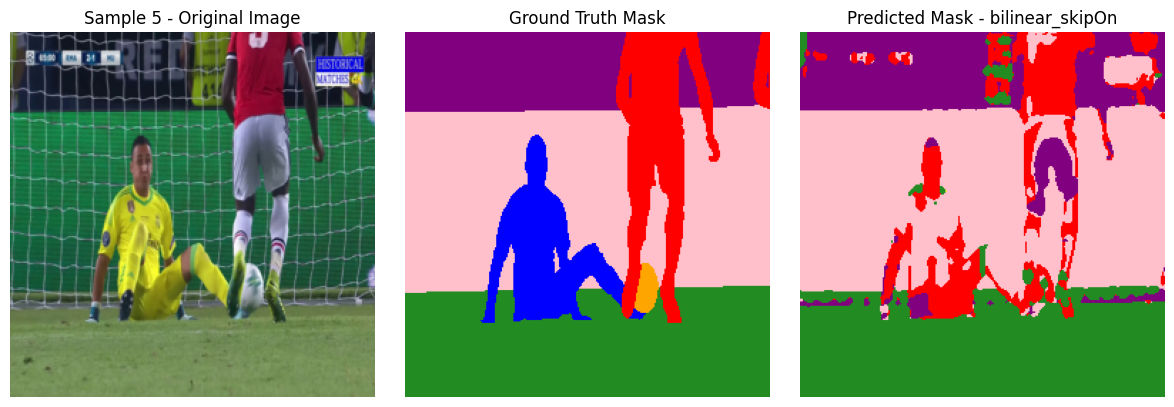

Showing sample 5 (0 to 19)


In [42]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# change this number to see different samples (0 to 9)
sample_number = 5

# change this to select different model:
# options: bilinear_skipOn, bilinear_skipOff, transposed_skipOn, transposed_skipOff
model_name = "bilinear_skipOn"

homework_code = Path.cwd()
import sys
sys.path.append(str(homework_code))

from data.data_loader import load_config, collect_dataset1_pairs, collect_dataset2_pairs
from data.data_loader import FootballSegDataset, parse_color_map
from sklearn.model_selection import train_test_split

# 1. load config file
config_path = homework_code / "config" / "config.yaml"
config = load_config(str(config_path))

# 2. color mappings for both datasets
color_map1 = parse_color_map(config["dataset1_color_to_unified"])
color_map2 = parse_color_map(config["dataset2_color_to_unified"])
num_classes = config["classes"]["num_classes"]
image_size = config["data"]["image_size"]

# 3. collect image-mask pairs
config_dir = config_path.parent.parent
ds1_imgs = str(config_dir / config["data"]["dataset1_images"])
ds1_masks = str(config_dir / config["data"]["dataset1_masks"])
ds2_dir = str(config_dir / config["data"]["dataset2_dir"])

pairs1 = collect_dataset1_pairs(ds1_imgs, ds1_masks)
pairs2 = collect_dataset2_pairs(ds2_dir)
all_pairs = pairs1 + pairs2

# 4. split into train and validation
labels = [p[2] for p in all_pairs]
train_pairs, val_pairs = train_test_split(
    all_pairs, 
    test_size=config["data"]["val_split"], 
    random_state=42, 
    stratify=labels
)

print(f"Train: {len(train_pairs)}, Val: {len(val_pairs)}")

# 5. create validation dataset (without DataLoader)
val_dataset = FootballSegDataset(
    val_pairs, color_map1, color_map2,
    num_classes, image_size, augment=False
)

print(f"Validation samples: {len(val_dataset)}")

# 6. configure model based on selected model_name
if "bilinear" in model_name:
    config['model']['upsample_mode'] = "bilinear"
else:
    config['model']['upsample_mode'] = "transposed"

# fix: check for skipOn not skipOّff (there was a typo)
config['model']['skip_connections'] = "skipOn" in model_name

print(f"Upsample mode: {config['model']['upsample_mode']}")
print(f"Skip connections: {config['model']['skip_connections']}")

# 7. load model
from models.model import build_model

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

model = build_model(config).to(device)
model_path = homework_code / "results" / model_name / "best_model.pth"

if not model_path.exists():
    print(f"Model not found: {model_path}")
    print("Available models:")
    results_dir = homework_code / "results"
    if results_dir.exists():
        for d in results_dir.iterdir():
            if d.is_dir():
                print(f"  - {d.name}")
else:
    checkpoint = torch.load(model_path, map_location=device)
    model.load_state_dict(checkpoint['model_state'])
    model.eval()
    print(f"Model loaded: {model_name}")

    # 8. convert class mask to RGB for display
    def mask_to_rgb(mask):
        colors = [
            (0,0,0), (34,139,34), (255,0,0), (0,0,255),
            (255,255,0), (255,165,0), (139,69,19), (255,192,203),
            (128,0,128), (169,169,169)
        ]
        h, w = mask.shape
        rgb = np.zeros((h, w, 3), dtype=np.uint8)
        for c in range(10):
            rgb[mask == c] = colors[c]
        return rgb

    # 9. get sample from validation set
    if sample_number >= len(val_dataset):
        print(f"Sample {sample_number} not available. Max is {len(val_dataset)-1}")
        sample_number = 0

    img, true_mask = val_dataset[sample_number]
    img = img.unsqueeze(0).to(device)
    true_mask = true_mask.cpu().numpy()

    # 10. run prediction
    with torch.no_grad():
        pred_mask = model(img).argmax(dim=1)[0].cpu().numpy()

    # 11. display results
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    # denormalize image for display
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img_disp = img[0].cpu().numpy().transpose(1,2,0) * std + mean
    img_disp = np.clip(img_disp, 0, 1)
    axes[0].imshow(img_disp)
    axes[0].set_title(f'Sample {sample_number} - Original Image')
    axes[0].axis('off')

    # ground truth mask
    axes[1].imshow(mask_to_rgb(true_mask))
    axes[1].set_title('Ground Truth Mask')
    axes[1].axis('off')

    # predicted mask
    axes[2].imshow(mask_to_rgb(pred_mask))
    axes[2].set_title(f'Predicted Mask - {model_name}')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

    print(f"Showing sample {sample_number} (0 to {len(val_dataset)-1})")

Train: 180, Val: 20
Validation samples: 20
Device: cpu
Loaded: bilinear_skipOn
Loaded: bilinear_skipOff
Loaded: transposed_skipOn
Loaded: transposed_skipOff

Displaying 20 samples for 4 models...


Exception ignored while calling deallocator <function _ConnectionBase.__del__ at 0x000001FFC74F9B10>:
Traceback (most recent call last):
  File "c:\Users\Rayanafshan\AppData\Local\Programs\Python\Python314\Lib\multiprocessing\connection.py", line 135, in __del__
    self._close()
  File "c:\Users\Rayanafshan\AppData\Local\Programs\Python\Python314\Lib\multiprocessing\connection.py", line 288, in _close
    _CloseHandle(self._handle)
OSError: [WinError 6] The handle is invalid
Exception ignored while calling deallocator <function _ConnectionBase.__del__ at 0x000001FFC74F9B10>:
Traceback (most recent call last):
  File "c:\Users\Rayanafshan\AppData\Local\Programs\Python\Python314\Lib\multiprocessing\connection.py", line 135, in __del__
    self._close()
  File "c:\Users\Rayanafshan\AppData\Local\Programs\Python\Python314\Lib\multiprocessing\connection.py", line 288, in _close
    _CloseHandle(self._handle)
OSError: [WinError 6] The handle is invalid


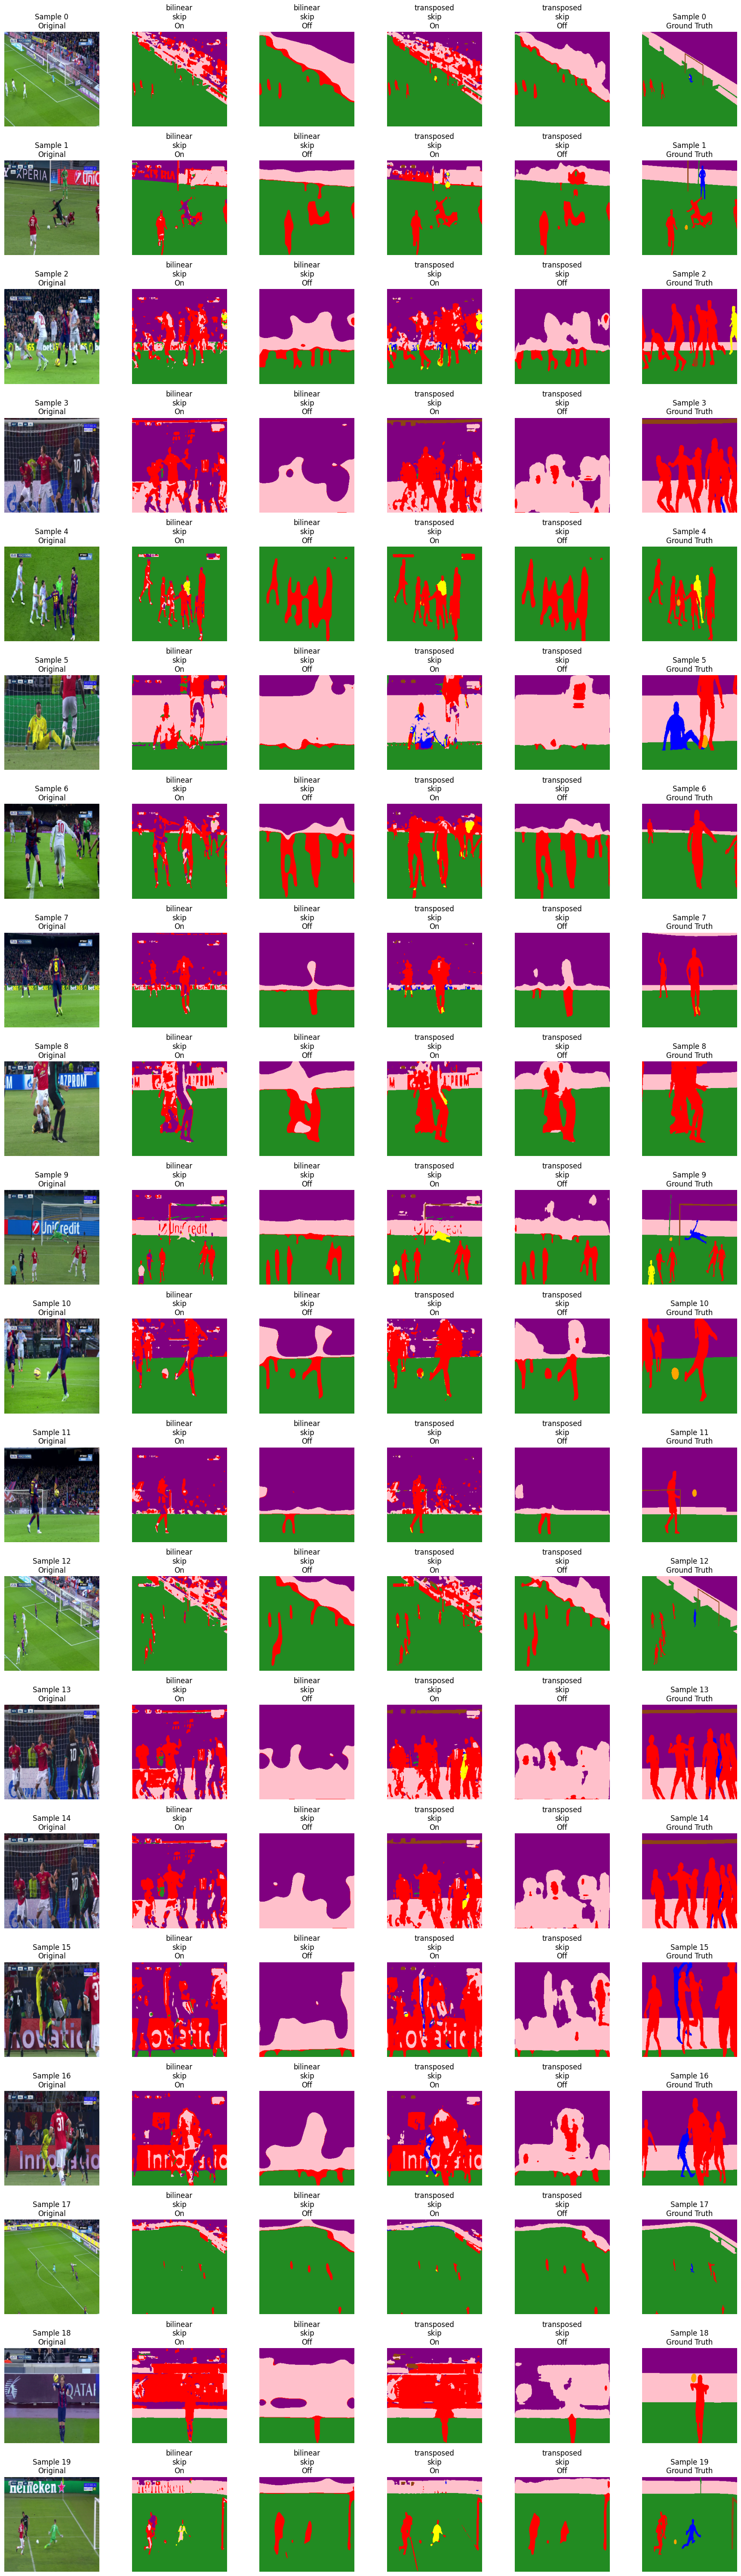


Summary:
  Total samples: 20
  Models evaluated: ['bilinear_skipOn', 'bilinear_skipOff', 'transposed_skipOn', 'transposed_skipOff']


In [44]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

homework_code = Path.cwd()
import sys
sys.path.append(str(homework_code))

from data.data_loader import load_config, collect_dataset1_pairs, collect_dataset2_pairs
from data.data_loader import FootballSegDataset, parse_color_map
from sklearn.model_selection import train_test_split

# 1. load config file
config_path = homework_code / "config" / "config.yaml"
config = load_config(str(config_path))

# 2. color mappings for both datasets
color_map1 = parse_color_map(config["dataset1_color_to_unified"])
color_map2 = parse_color_map(config["dataset2_color_to_unified"])
num_classes = config["classes"]["num_classes"]
image_size = config["data"]["image_size"]

# 3. collect image-mask pairs
config_dir = config_path.parent.parent
ds1_imgs = str(config_dir / config["data"]["dataset1_images"])
ds1_masks = str(config_dir / config["data"]["dataset1_masks"])
ds2_dir = str(config_dir / config["data"]["dataset2_dir"])

pairs1 = collect_dataset1_pairs(ds1_imgs, ds1_masks)
pairs2 = collect_dataset2_pairs(ds2_dir)
all_pairs = pairs1 + pairs2

# 4. split into train and validation
labels = [p[2] for p in all_pairs]
train_pairs, val_pairs = train_test_split(
    all_pairs, 
    test_size=config["data"]["val_split"], 
    random_state=42, 
    stratify=labels
)

print(f"Train: {len(train_pairs)}, Val: {len(val_pairs)}")

# 5. create validation dataset
val_dataset = FootballSegDataset(
    val_pairs, color_map1, color_map2,
    num_classes, image_size, augment=False
)

print(f"Validation samples: {len(val_dataset)}")

# 6. convert class mask to RGB for display
def mask_to_rgb(mask):
    colors = [
        (0,0,0), (34,139,34), (255,0,0), (0,0,255),
        (255,255,0), (255,165,0), (139,69,19), (255,192,203),
        (128,0,128), (169,169,169)
    ]
    h, w = mask.shape
    rgb = np.zeros((h, w, 3), dtype=np.uint8)
    for c in range(10):
        rgb[mask == c] = colors[c]
    return rgb

# 7. denormalize image function
def denormalize_image(img_tensor):
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = img_tensor.cpu().numpy().transpose(1,2,0) * std + mean
    img = np.clip(img, 0, 1)
    return img

# 8. list of all 4 models
models_to_evaluate = [
    {"name": "bilinear_skipOn", "upsample": "bilinear", "skip": True},
    {"name": "bilinear_skipOff", "upsample": "bilinear", "skip": False},
    {"name": "transposed_skipOn", "upsample": "transposed", "skip": True},
    {"name": "transposed_skipOff", "upsample": "transposed", "skip": False},
]

# 9. load all models
from models.model import build_model

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

loaded_models = {}

for model_info in models_to_evaluate:
    model_name = model_info["name"]
    config['model']['upsample_mode'] = model_info["upsample"]
    config['model']['skip_connections'] = model_info["skip"]
    
    model = build_model(config).to(device)
    model_path = homework_code / "results" / model_name / "best_model.pth"
    
    if model_path.exists():
        checkpoint = torch.load(model_path, map_location=device)
        model.load_state_dict(checkpoint['model_state'])
        model.eval()
        loaded_models[model_name] = model
        print(f"Loaded: {model_name}")
    else:
        print(f"Not found: {model_name}")

# 10. display results for all samples and all models
num_samples = len(val_dataset)
num_models = len(loaded_models)

print(f"\nDisplaying {num_samples} samples for {num_models} models...")

# create figure: rows = num_samples, columns = 1 (original) + num_models (predictions) + 1 (ground truth)
fig, axes = plt.subplots(num_samples, 2 + num_models, figsize=(3 * (2 + num_models), 3 * num_samples))

# handle single sample case
if num_samples == 1:
    axes = axes.reshape(1, -1)

for sample_idx in range(num_samples):
    img, true_mask = val_dataset[sample_idx]
    img_tensor = img.unsqueeze(0).to(device)
    true_mask_np = true_mask.cpu().numpy()
    
    # column 0: original image
    axes[sample_idx, 0].imshow(denormalize_image(img))
    axes[sample_idx, 0].set_title(f'Sample {sample_idx}\nOriginal')
    axes[sample_idx, 0].axis('off')
    
    # column 1 to 1+num_models: predictions from each model
    col_idx = 1
    for model_name, model in loaded_models.items():
        with torch.no_grad():
            pred_mask = model(img_tensor).argmax(dim=1)[0].cpu().numpy()
        
        axes[sample_idx, col_idx].imshow(mask_to_rgb(pred_mask))
        # short name for display
        short_name = model_name.replace("_", "\n").replace("skipOn", "skip\nOn").replace("skipOff", "skip\nOff")
        axes[sample_idx, col_idx].set_title(f'{short_name}')
        axes[sample_idx, col_idx].axis('off')
        col_idx += 1
    
    # last column: ground truth
    axes[sample_idx, -1].imshow(mask_to_rgb(true_mask_np))
    axes[sample_idx, -1].set_title(f'Sample {sample_idx}\nGround Truth')
    axes[sample_idx, -1].axis('off')

plt.tight_layout()
plt.show()

print(f"\nSummary:")
print(f"  Total samples: {num_samples}")
print(f"  Models evaluated: {list(loaded_models.keys())}")